# Preparing 
`preparing.ipynb` thực hiện quy trình xử lý dữ liệu theo thứ tự:

EDA → Data Cleaning → Data Preparing

Mục tiêu là kiểm tra chất lượng dữ liệu, xử lý các vấn đề phát hiện được và chuẩn bị dataset cho các bước phân tích / modeling tiếp theo.


# 0. Problem Definition

## Bài toán

Nghiên cứu khả năng ứng dụng **Trí tuệ nhân tạo (Artificial Intelligence - AI)** trong phân tích **dữ liệu cảm biến sinh học*** nhằm:

- Hỗ trợ phát hiện sớm các dấu hiệu bệnh.
- Dự đoán hoặc phân loại bệnh dựa trên dữ liệu đầu vào.
- Đánh giá hiệu quả của các mô hình AI trên từng loại dữ liệu.
- Phân tích ưu điểm, hạn chế và khả năng ứng dụng của các mô hình AI trong thực tế.

## Input

Bao gồm các chỉ số sinh tồn và tín hiệu sinh học, chẳng hạn như:

- Heart Rate (HR)
- Blood Oxygen Saturation (SpO₂)
- Blood Pressure (BP)
- Body Temperature
- Respiratory Rate (RR)
- Electrocardiogram (ECG)
- Photoplethysmography (PPG)
- Các tín hiệu sinh học khác từ thiết bị đeo hoặc cảm biến y tế

## Output

Hệ thống AI cần cung cấp:

- Kết quả dự đoán hoặc phân loại bệnh/nguy cơ mắc bệnh.
- Xác suất hoặc mức độ tin cậy của dự đoán (Confidence/Probability).
- Các chỉ số đánh giá mô hình, bao gồm:
  - Accuracy
  - Precision
  - Recall (Sensitivity)
  - Specificity
  - F1-score
  - ROC-AUC
- Phân tích và so sánh hiệu quả giữa các mô hình AI trên từng loại dữ liệu và từng bài toán.
## Dataset mặc định

Nghiên cứu sử dụng **các bộ dữ liệu y khoa công khai (Public Medical Datasets)** nhằm đảm bảo tính minh bạch, khả năng tái lập và dễ dàng so sánh kết quả.
Các bộ dữ liệu chứa thông tin về:

- Heart Rate (HR)
- SpO₂
- Blood Pressure (BP)
- Respiratory Rate (RR)
- ECG
- PPG
- Các chỉ số sinh tồn khác thu thập từ thiết bị y tế hoặc thiết bị đeo thông minh


# 1. EDA - Phân tích khám phá dữ liệu CBC

**Mục tiêu:** Thực hiện EDA trên bộ dữ liệu `CBC.csv` (Complete Blood Count - Công thức máu) **trước khi bước làm sạch**. Chỉ đọc, phân tích và báo cáo. **Tuyệt đối không tiền xử lý, không điền khuyết, không xóa dòng.**

---

## Yêu cầu phân tích

### 1. Data Profiling & Health Check
- Liệt kê các cột, kiểu dữ liệu.
- Phát hiện giá trị bất thường mang tính kỹ thuật hệ thống (ví dụ: `5.397605346934028e-79`).

### 2. Distribution & Biological Outliers
- Đánh giá nhanh phân phối của các chỉ số sinh huyết.
- Xác định cột nào có nguy cơ chứa outlier sinh học quan trọng (cần lưu ý, không xóa vội).

### 3. Missingness & Artifact Risks
- Đánh giá tỷ lệ và mô hình missing data.
- Phân tích rủi ro từ artifact values (giá trị kỹ thuật giả).

### 4. Project Gap Analysis
- Phần nào thực sự cần thiết cho bước Clean/Prep tiếp theo?
- Dự án hiện tại **còn thiếu** những yếu tố gì (target/label, metadata, clinical context...) để huấn luyện AI?

---

**Lưu ý:** Output chỉ dùng để đánh giá chất lượng dữ liệu và lập kế hoạch làm sạch. Không sửa đổi dữ liệu gốc.

1. DATA PROFILING & HEALTH CHECK
Shape: 9165 rows x 21 columns

Columns (21):
   1. SEQN            | dtype: float64    | non-null: 9165
   2. LBXWBCSI        | dtype: float64    | non-null: 8117
   3. LBXLYPCT        | dtype: float64    | non-null: 8116
   4. LBXMOPCT        | dtype: float64    | non-null: 8116
   5. LBXNEPCT        | dtype: float64    | non-null: 8116
   6. LBXEOPCT        | dtype: float64    | non-null: 8116
   7. LBXBAPCT        | dtype: float64    | non-null: 8116
   8. LBDLYMNO        | dtype: float64    | non-null: 8116
   9. LBDMONO         | dtype: float64    | non-null: 8116
  10. LBDNENO         | dtype: float64    | non-null: 8116
  11. LBDEONO         | dtype: float64    | non-null: 8116
  12. LBDBANO         | dtype: float64    | non-null: 8116
  13. LBXRBCSI        | dtype: float64    | non-null: 8117
  14. LBXHGB          | dtype: float64    | non-null: 8117
  15. LBXHCT          | dtype: float64    | non-null: 8117
  16. LBXMCVSI        | dtype: float6

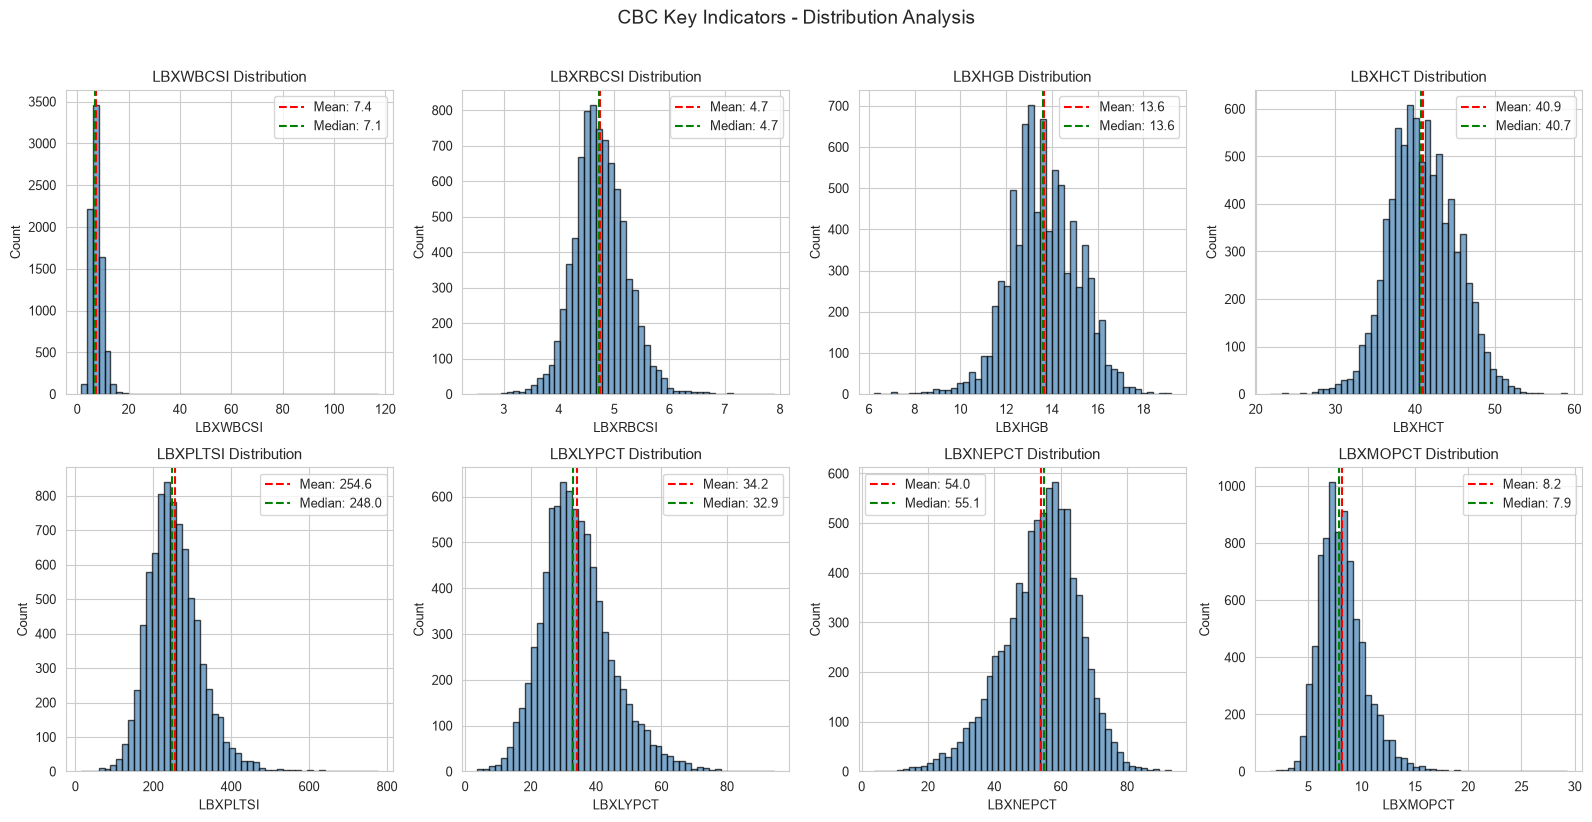

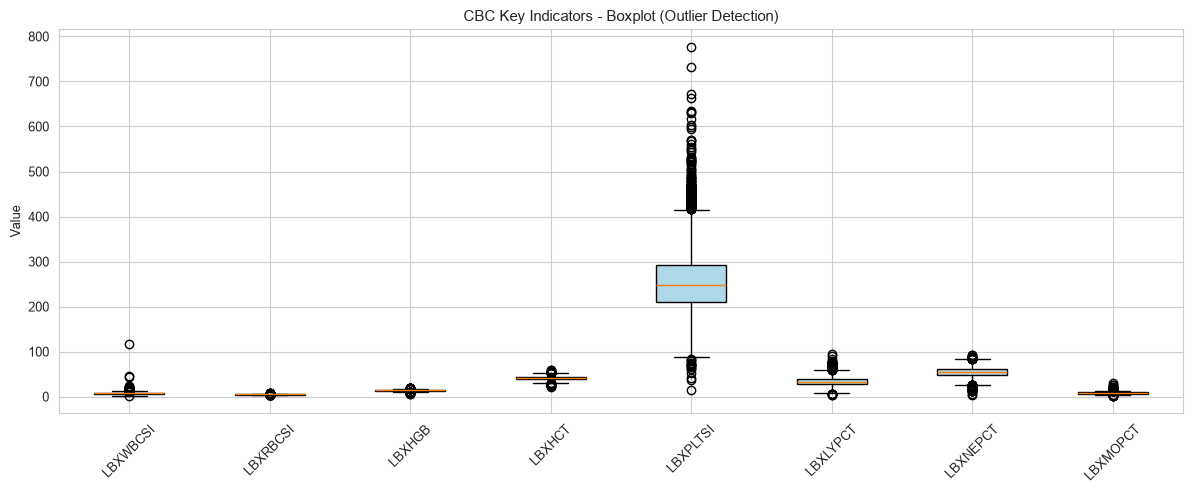

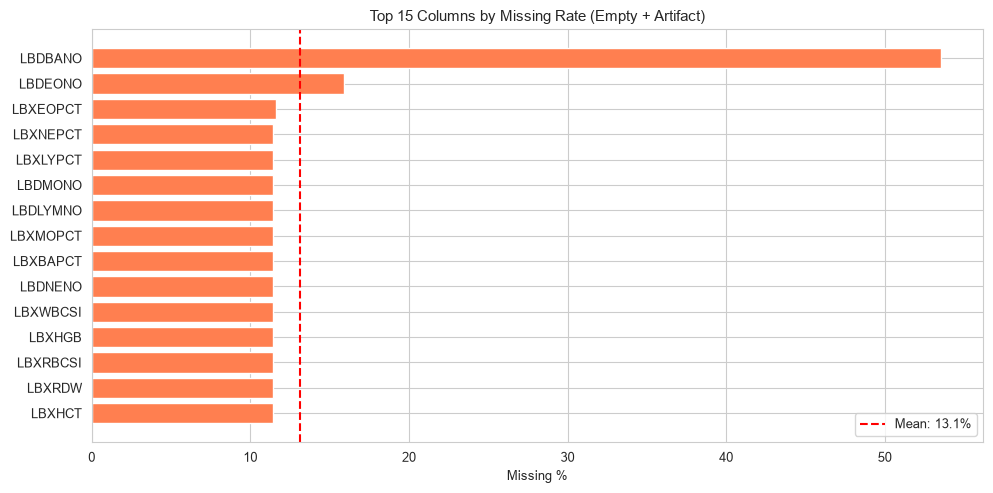

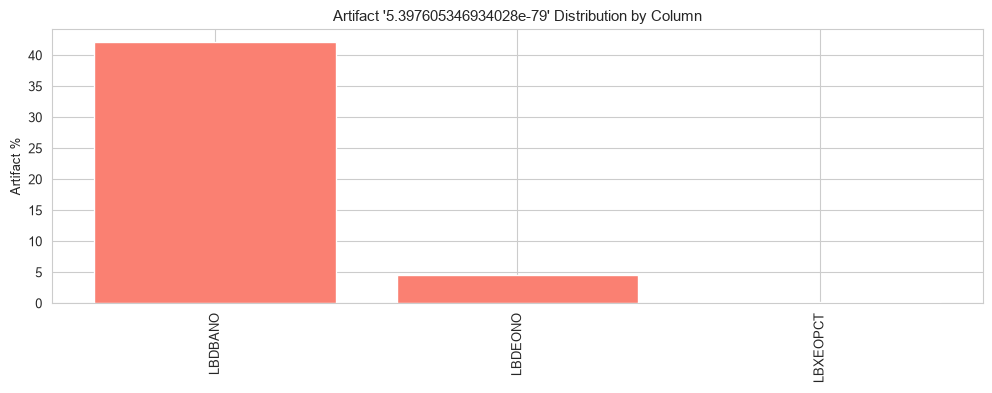

In [11]:
import pandas as pd
import numpy as np

# ============================================
# 1. LOAD DATA & BASIC PROFILING
# ============================================
df = pd.read_csv("../Dataset/CBC.csv")

print("=" * 60)
print("1. DATA PROFILING & HEALTH CHECK")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    non_null = df[col].notna().sum()
    print(f"  {i:2d}. {col:<15} | dtype: {str(dtype):<10} | non-null: {non_null}")

# Detect technical artifacts (NHANES placeholder)
artifact_val = "5.397605346934028e-79"
artifact_mask = df.apply(lambda row: row.astype(str).str.contains(artifact_val, na=False)).any(axis=1)
artifact_rows = artifact_mask.sum()
print(f"\n[!] Rows containing artifact '{artifact_val}': {artifact_rows} ({artifact_rows/len(df)*100:.1f}%)")

# Identify columns with artifact
artifact_cols = []
for col in df.columns:
    count = df[col].astype(str).str.contains(artifact_val, na=False).sum()
    if count > 0:
        artifact_cols.append((col, count))
print("\nColumns affected by artifact:")
for col, cnt in artifact_cols:
    print(f"  - {col}: {cnt} cells")

# ============================================
# 2. DISTRIBUTION & BIOLOGICAL OUTLIERS
# ============================================
print("\n" + "=" * 60)
print("2. DISTRIBUTION & BIOLOGICAL OUTLIERS")
print("=" * 60)

# Key hematology indicators
bio_cols = [
    "LBXWBCSI", "LBXRBCSI", "LBXHGB", "LBXHCT",
    "LBXPLTSI", "LBXLYPCT", "LBXNEPCT", "LBXMOPCT"
]

for col in bio_cols:
    if col not in df.columns:
        continue
    # Convert to numeric, coerce errors
    numeric = pd.to_numeric(df[col], errors="coerce")
    # Exclude artifact
    clean = numeric[(numeric.notna()) & (~df[col].astype(str).str.contains(artifact_val, na=False))]
    
    if len(clean) == 0:
        continue
    
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = clean[(clean < lower) | (clean > upper)]
    
    print(f"\n{col}:")
    print(f"  Valid range (IQR): [{lower:.2f}, {upper:.2f}]")
    print(f"  Actual min/max: [{clean.min():.2f}, {clean.max():.2f}]")
    print(f"  Mean: {clean.mean():.2f} | Std: {clean.std():.2f}")
    print(f"  Potential outliers (IQR): {len(outliers)} ({len(outliers)/len(clean)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  -> Outlier range: [{outliers.min():.2f}, {outliers.max():.2f}]")
        print(f"  -> CAUTION: Biological outliers need clinical review before removal.")

# ============================================
# 3. MISSINGNESS & ARTIFACT RISKS
# ============================================
print("\n" + "=" * 60)
print("3. MISSINGNESS & ARTIFACT RISKS")
print("=" * 60)

# Count empty strings and artifact
missing_stats = []
for col in df.columns:
    empty_mask = df[col].isna() | (df[col].astype(str).str.strip() == "")
    artifact_mask_col = df[col].astype(str).str.contains(artifact_val, na=False)
    
    empty_cnt = empty_mask.sum()
    artifact_cnt = artifact_mask_col.sum()
    total_missing = empty_cnt + artifact_cnt
    
    missing_stats.append({
        "column": col,
        "empty": empty_cnt,
        "artifact": artifact_cnt,
        "total_missing": total_missing,
        "missing_pct": total_missing / len(df) * 100
    })

missing_df = pd.DataFrame(missing_stats)
missing_df = missing_df.sort_values("missing_pct", ascending=False)
print("\nTop 10 columns with highest missingness:")
print(missing_df.head(10).to_string(index=False))

print(f"\nTotal missing cells (empty + artifact): {missing_df['total_missing'].sum()}")
print(f"Overall missing rate: {missing_df['total_missing'].sum() / (len(df) * len(df.columns)) * 100:.2f}%")

print("\n[!] ARTIFACT RISK ASSESSMENT:")
print(f"    - Artifact value '{artifact_val}' appears in {artifact_rows} rows ({artifact_rows/len(df)*100:.1f}%)")
print(f"    - This is a system placeholder (likely NHANES coding), NOT a real measurement.")
print(f"    - If treated as numeric, it will distort statistics (underflow to ~0).")
print(f"    - RISK: Model may learn this artifact as a valid near-zero feature if not handled in Clean step.")

# ============================================
# 4. PROJECT GAP ANALYSIS
# ============================================
print("\n" + "=" * 60)
print("4. PROJECT GAP ANALYSIS")
print("=" * 60)

print("\nWhat is NEEDED for Clean/Prep next step:")
print("  [ ] Consistent handling of artifact values (replace with NaN or proper missing code)")
print("  [ ] Decision on outlier treatment: cap / remove / flag (requires clinical input)")
print("  [ ] Imputation strategy per column (mean/median/knn/mice)")
print("  [ ] Validation of biological plausibility ranges per indicator")
print("  [ ] Handling of partial missing rows (e.g., some labs present, others absent)")

print("\nWhat is MISSING for successful AI training:")
print("  [x] Data: Raw measurements present (CBC indices)")
print("  [ ] Target / Label: NO disease status, diagnosis, or clinical outcome column found.")
print("  [ ] Demographics: NO age, sex, ethnicity, BMI for stratification or confounding control.")
print("  [ ] Metadata: NO collection site, device model, assay method (batch effects risk).")
print("  [ ] Temporal info: NO timestamp or patient ID linkage for longitudinal or deduplication.")
print("  [ ] Clinical context: NO comorbidity, medication, or symptom data for feature engineering.")
print("  [ ] Train/Val/Test split strategy: Not yet defined.")

print("\n" + "=" * 60)
print("EDA COMPLETE - No data was modified.")

# ============================================
# 5. VISUALIZATION - CBC
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 9
sns.set_style("whitegrid")

# --- Histograms for key hematology indicators ---
bio_cols = [
    "LBXWBCSI", "LBXRBCSI", "LBXHGB", "LBXHCT",
    "LBXPLTSI", "LBXLYPCT", "LBXNEPCT", "LBXMOPCT"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for idx, col in enumerate(bio_cols):
    if col not in df.columns:
        continue
    numeric = pd.to_numeric(df[col], errors="coerce")
    clean = numeric[(numeric.notna()) & (~df[col].astype(str).str.contains(artifact_val, na=False))]
    if len(clean) == 0:
        continue
    axes[idx].hist(clean, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
    axes[idx].set_title(f"{col} Distribution")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")
    axes[idx].axvline(clean.mean(), color="red", linestyle="--", label=f"Mean: {clean.mean():.1f}")
    axes[idx].axvline(clean.median(), color="green", linestyle="--", label=f"Median: {clean.median():.1f}")
    axes[idx].legend()

for idx in range(len(bio_cols), len(axes)):
    axes[idx].axis("off")

plt.suptitle("CBC Key Indicators - Distribution Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Boxplots for outlier visualization ---
fig, ax = plt.subplots(figsize=(12, 5))
box_data = []
box_labels = []
for col in bio_cols:
    if col not in df.columns:
        continue
    numeric = pd.to_numeric(df[col], errors="coerce")
    clean = numeric[(numeric.notna()) & (~df[col].astype(str).str.contains(artifact_val, na=False))]
    if len(clean) > 0:
        box_data.append(clean)
        box_labels.append(col)

bp = ax.boxplot(box_data, tick_labels=box_labels, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightblue")
ax.set_title("CBC Key Indicators - Boxplot (Outlier Detection)")
ax.set_ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Missingness bar chart ---
missing_sorted = missing_df.head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing_sorted["column"][::-1], missing_sorted["missing_pct"][::-1], color="coral")
ax.set_xlabel("Missing %")
ax.set_title("Top 15 Columns by Missing Rate (Empty + Artifact)")
ax.axvline(missing_df["missing_pct"].mean(), color="red", linestyle="--", label=f"Mean: {missing_df['missing_pct'].mean():.1f}%")
ax.legend()
plt.tight_layout()
plt.show()

# --- Artifact impact visualization ---
artifact_stats = []
for col in df.columns:
    cnt = df[col].astype(str).str.contains(artifact_val, na=False).sum()
    if cnt > 0:
        artifact_stats.append({"column": col, "artifact_count": cnt, "artifact_pct": cnt/len(df)*100})

if artifact_stats:
    art_df = pd.DataFrame(artifact_stats).sort_values("artifact_pct", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(art_df["column"], art_df["artifact_pct"], color="salmon")
    ax.set_ylabel("Artifact %")
    ax.set_title(f"Artifact '{artifact_val}' Distribution by Column")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
print("=" * 60)


# 2. EDA - Phân tích khám phá dữ liệu Diseases_and_Symptoms

**Mục tiêu:** Thực hiện EDA trên bộ dữ liệu `Diseases_and_Symptoms.csv` (dạng bảng nhị phân/thưa thớt gồm triệu chứng và nhãn bệnh lý) **trước khi đưa vào huấn luyện mô hình AI**. Chỉ đọc, phân tích và báo cáo. **Tuyệt đối không viết code huấn luyện mô hình vội.**

---

## Yêu cầu phân tích

### 1. Data Profile & Sparsity
- Đánh giá nhanh đặc thù dữ liệu: số lượng biến đặc trưng, tỷ lệ giá trị 0 và 1, mức độ thưa thớt của ma trận.
- Xác định xem đây là multi-label hay single-label classification.

### 2. Feature Insights & Clustering
- Nhận diện các nhóm triệu chứng có xu hướng đi kèm nhau (đồng xuất hiện) dựa trên tên cột và ngữ cảnh dữ liệu.
- Chỉ ra cột nào có thể gây nhiễu do quá ít biến động (quasi-constant).

### 3. Machine Learning Risks
- Cảnh báo các rủi ro kỹ thuật khi huấn luyện trên dữ liệu dạng này: Curse of Dimensionality, mất cân bằng lớp (class imbalance), sparsity issues.

### 4. Data Gap & Next Steps
- Chỉ ra những phần còn thiếu (dữ liệu nhân khẩu học, trọng số triệu chứng, metadata...) 
- Đề xuất phương án xử lý trước khi đưa vào thuật toán phân loại (Random Forest, XGBoost, Neural Network).

---

**Lưu ý:** Output chỉ dùng để đánh giá chất lượng dữ liệu và lập kế hoạch tiền xử lý. Không sửa đổi dữ liệu gốc.

1. DATA PROFILE & SPARSITY
Shape: 246945 rows x 378 columns
Target column: diseases
Feature columns: 377

Data types (first 10):
diseases                              str
anxiety and nervousness             int64
depression                          int64
shortness of breath                 int64
depressive or psychotic symptoms    int64
sharp chest pain                    int64
dizziness                           int64
insomnia                            int64
abnormal involuntary movements      int64
chest tightness                     int64
dtype: object

Sparsity Analysis:
  Total cells: 93,098,265
  Ones (1): 1,316,921 (1.41%)
  Zeros (0): 91,781,344 (98.59%)
  Missing (NaN): 0 (0.00%)
  Sparsity (zeros + missing): 98.59%

Number of unique diseases (classes): 773

Top 10 most frequent diseases:
diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis              

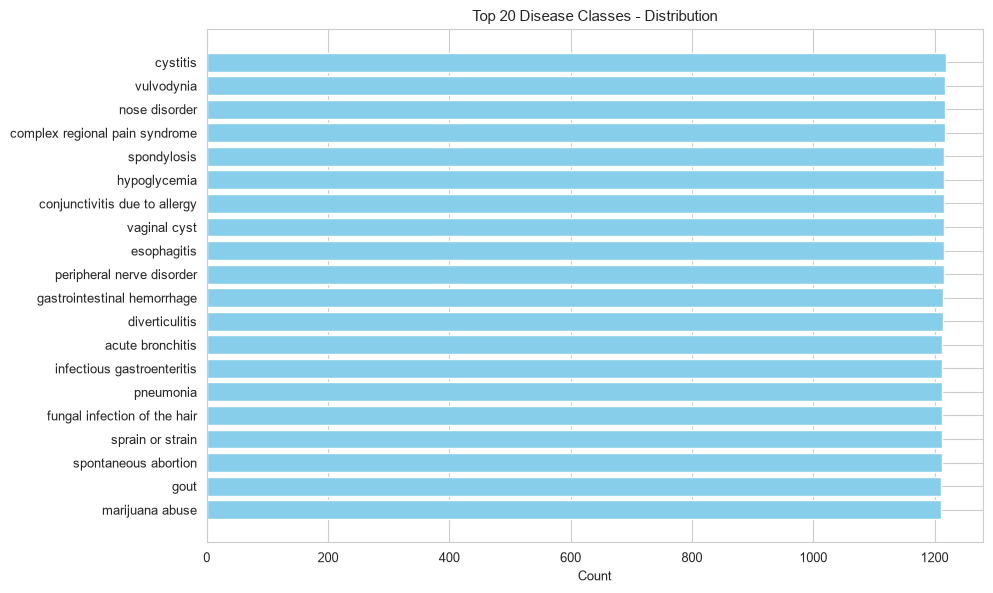

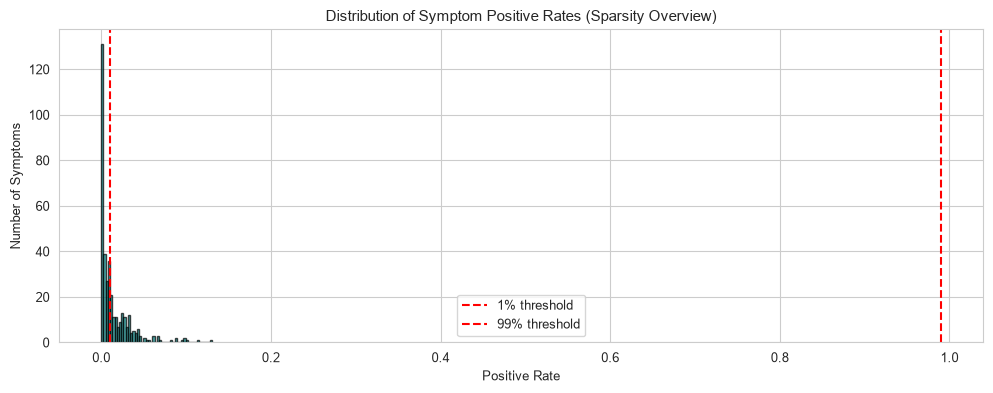

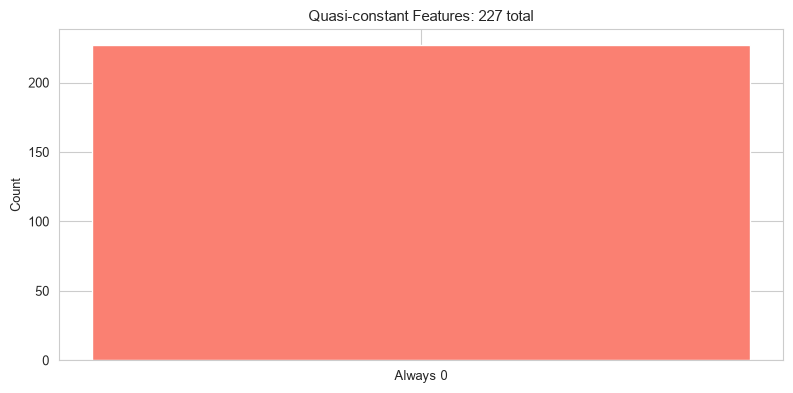

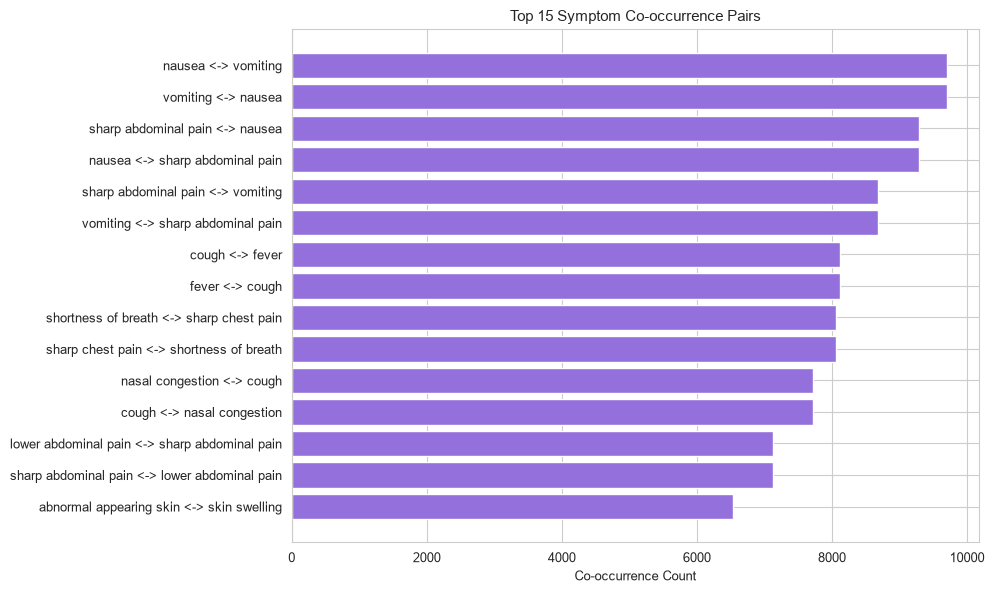

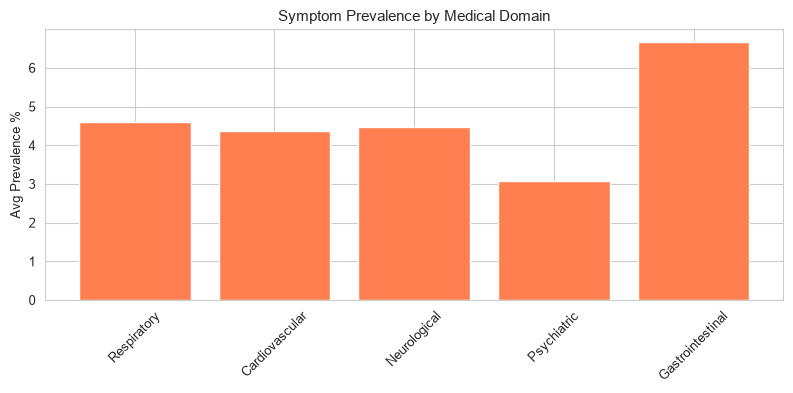

In [12]:
import pandas as pd
import numpy as np

# ============================================
# 1. LOAD DATA & BASIC PROFILE
# ============================================
df = pd.read_csv("../Dataset/Diseases_and_Symptoms.csv")

print("=" * 60)
print("1. DATA PROFILE & SPARSITY")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

target_col = "diseases"
feature_cols = [c for c in df.columns if c != target_col]
print(f"Target column: {target_col}")
print(f"Feature columns: {len(feature_cols)}")

# Data types
print("\nData types (first 10):")
print(df.dtypes.head(10))

# Sparsity analysis
X = df[feature_cols]
total_cells = X.shape[0] * X.shape[1]
ones = (X == 1).sum().sum()
zeros = (X == 0).sum().sum()
missing = X.isna().sum().sum()

print(f"\nSparsity Analysis:")
print(f"  Total cells: {total_cells:,}")
print(f"  Ones (1): {ones:,} ({ones/total_cells*100:.2f}%)")
print(f"  Zeros (0): {zeros:,} ({zeros/total_cells*100:.2f}%)")
print(f"  Missing (NaN): {missing:,} ({missing/total_cells*100:.2f}%)")
print(f"  Sparsity (zeros + missing): {(zeros+missing)/total_cells*100:.2f}%")

# Check if multi-label or single-label
label_counts = df[target_col].value_counts()
print(f"\nNumber of unique diseases (classes): {len(label_counts)}")
print(f"\nTop 10 most frequent diseases:")
print(label_counts.head(10).to_string())
print(f"\nBottom 10 least frequent diseases:")
print(label_counts.tail(10).to_string())

# Class imbalance check
print(f"\nClass Imbalance Check:")
print(f"  Most frequent class: {label_counts.iloc[0]} ({label_counts.iloc[0]/len(df)*100:.1f}%)")
print(f"  Least frequent class: {label_counts.iloc[-1]} ({label_counts.iloc[-1]/len(df)*100:.1f}%)")
print(f"  Imbalance ratio (max/min): {label_counts.iloc[0]/label_counts.iloc[-1]:.1f}x")

# ============================================
# 2. FEATURE INSIGHTS & CLUSTERING
# ============================================
print("\n" + "=" * 60)
print("2. FEATURE INSIGHTS & CLUSTERING")
print("=" * 60)

# Feature variance analysis (quasi-constant detection)
feature_counts = X.sum().sort_values(ascending=False)
print(f"\nTop 10 most frequent symptoms (positive rate):")
for feat, cnt in feature_counts.head(10).items():
    pct = cnt / len(df) * 100
    print(f"  {feat}: {cnt:,} ({pct:.1f}%)")

print(f"\nBottom 10 least frequent symptoms (potential rare/noise features):")
for feat, cnt in feature_counts.tail(10).items():
    pct = cnt / len(df) * 100
    print(f"  {feat}: {cnt:,} ({pct:.1f}%)")

# Quasi-constant features (>99% zeros or >99% ones)
quasi_const = []
for feat in feature_cols:
    pos_rate = X[feat].mean()
    if pos_rate > 0.99 or pos_rate < 0.01:
        quasi_const.append((feat, pos_rate))

print(f"\nQuasi-constant features (>99% zeros or >99% ones): {len(quasi_const)}")
for feat, rate in quasi_const[:10]:
    print(f"  {feat}: {rate*100:.1f}% positive")
if len(quasi_const) > 10:
    print(f"  ... and {len(quasi_const)-10} more")

# Symptom co-occurrence (top pairs)
co_matrix = X.T.dot(X)
co_series = co_matrix.unstack()
co_series = co_series[co_series.index.get_level_values(0) != co_series.index.get_level_values(1)]
co_series = co_series.sort_values(ascending=False)
print(f"\nTop 10 symptom co-occurrence pairs:")
for (s1, s2), cnt in co_series.head(10).items():
    print(f"  {s1} <-> {s2}: {cnt:,} times")

# Symptom groups by medical domain (based on column names)
domains = {
    "Respiratory": ["shortness of breath", "cough", "wheezing", "nasal congestion", "difficulty breathing", "coughing up sputum", "hemoptysis"],
    "Cardiovascular": ["palpitations", "irregular heartbeat", "chest tightness", "chest pain", "shortness of breath"],
    "Neurological": ["headache", "dizziness", "seizures", "paresthesia", "focal weakness"],
    "Psychiatric": ["anxiety", "depression", "insomnia", "restlessness"],
    "Gastrointestinal": ["vomiting", "nausea", "diarrhea", "abdominal pain", "constipation"]
}

print(f"\nDomain-based symptom groups (prevalence):")
for domain, symptoms in domains.items():
    present = [s for s in symptoms if s in X.columns]
    if present:
        mean_rate = X[present].mean().mean() * 100
        print(f"  {domain}: {len(present)} symptoms found, avg prevalence {mean_rate:.1f}%")

# ============================================
# 3. ML RISKS
# ============================================
print("\n" + "=" * 60)
print("3. MACHINE LEARNING RISKS")
print("=" * 60)

print(f"\n[!] CURSE OF DIMENSIONALITY:")
print(f"    - {len(feature_cols)} features for {len(df)} samples (feature/sample ratio: {len(feature_cols)/len(df):.2f})")
print(f"    - High-dimensional sparse data risks overfitting in linear models.")
print(f"    - Recommendation: Feature selection / dimensionality reduction before training.")

print(f"\n[!] CLASS IMBALANCE:")
print(f"    - Imbalance ratio: {label_counts.iloc[0]/label_counts.iloc[-1]:.1f}x (most vs least frequent class)")
print(f"    - Risk: Model may bias toward majority classes.")
print(f"    - Recommendation: Class weights, SMOTE, or stratified sampling.")

print(f"\n[!] SPARSITY IMPACT:")
print(f"    - {(zeros+missing)/total_cells*100:.1f}% sparsity may cause convergence issues for gradient-based models (NN, Logistic Regression).")
print(f"    - Tree-based models (RF, XGBoost) are more robust to sparse binary data.")

print(f"\n[!] LABEL CORRELATION RISK:")
# Check if diseases are mutually exclusive or overlapping
print(f"    - Current task type: Multi-class single-label (one disease per row).")
print(f"    - If diseases can co-occur, this should be multi-label classification.")

# ============================================
# 4. DATA GAP & NEXT STEPS
# ============================================
print("\n" + "=" * 60)
print("4. DATA GAP & NEXT STEPS")
print("=" * 60)

print(f"\nWhat is PRESENT:")
print(f"  [x] Binary symptom features ({len(feature_cols)} columns)")
print(f"  [x] Disease labels ({len(label_counts)} classes)")

print(f"\nWhat is MISSING for robust AI training:")
print(f"  [ ] Demographics: NO age, sex, BMI, ethnicity for confounding control.")
print(f"  [ ] Symptom severity/weight: NO intensity scale (only presence/absence).")
print(f"  [ ] Temporal info: NO onset time, duration, or progression pattern.")
print(f"  [ ] Metadata: NO patient ID, source/hospital, data collection method.")
print(f"  [ ] Comorbidity data: NO co-occurring diseases for multi-label learning.")
print(f"  [ ] Train/Val/Test split: Not yet defined (recommend stratified split).")

print(f"\nRECOMMENDED NEXT STEPS before modeling:")
print(f"  1. Remove quasi-constant features (variance threshold).")
print(f"  2. Address class imbalance (class weights or resampling).")
print(f"  3. Feature selection: SelectKBest, mutual_info_classif, or tree-based importance.")
print(f"  4. If >1000 features remain: consider dimensionality reduction (PCA, TruncatedSVD).")
print(f"  5. Verify label consistency: confirm single-label vs multi-label task.")
print(f"  6. Baseline model: Start with Random Forest / XGBoost (robust to sparse binary data).")
print(f"  7. Evaluation metrics: Use macro-F1 or weighted-F1 due to imbalance.")

print("\n" + "=" * 60)
print("EDA COMPLETE - No data was modified.")

# ============================================
# 5. VISUALIZATION - Diseases_and_Symptoms
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 9
sns.set_style("whitegrid")

# --- Class distribution (top 20 diseases) ---
fig, ax = plt.subplots(figsize=(10, 6))
top20 = label_counts.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color="skyblue")
ax.set_xlabel("Count")
ax.set_title("Top 20 Disease Classes - Distribution")
plt.tight_layout()
plt.show()

# --- Sparsity: histogram of positive rates ---
pos_rates = X.mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pos_rates, bins=50, color="teal", edgecolor="black", alpha=0.7)
ax.set_xlabel("Positive Rate")
ax.set_ylabel("Number of Symptoms")
ax.set_title("Distribution of Symptom Positive Rates (Sparsity Overview)")
ax.axvline(0.01, color="red", linestyle="--", label="1% threshold")
ax.axvline(0.99, color="red", linestyle="--", label="99% threshold")
ax.legend()
plt.tight_layout()
plt.show()

# --- Quasi-constant features summary ---
if quasi_const:
    qc_df = pd.DataFrame(quasi_const, columns=["feature", "pos_rate"])
    qc_df["category"] = qc_df["pos_rate"].apply(lambda x: "Always 1" if x > 0.99 else "Always 0")
    fig, ax = plt.subplots(figsize=(8, 4))
    qc_counts = qc_df["category"].value_counts()
    ax.bar(qc_counts.index, qc_counts.values, color=["salmon", "lightgreen"])
    ax.set_ylabel("Count")
    ax.set_title(f"Quasi-constant Features: {len(quasi_const)} total")
    plt.tight_layout()
    plt.show()

# --- Top 15 co-occurrence pairs heatmap ---
top_pairs = co_series.head(15)
pair_list = list(top_pairs.index)
pair_values = list(top_pairs.values)
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(pair_list))
ax.barh(y_pos, pair_values, color="mediumpurple")
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{s1} <-> {s2}" for (s1, s2) in pair_list])
ax.invert_yaxis()
ax.set_xlabel("Co-occurrence Count")
ax.set_title("Top 15 Symptom Co-occurrence Pairs")
plt.tight_layout()
plt.show()

# --- Domain prevalence comparison ---
domain_means = {}
for domain, symptoms in domains.items():
    present = [s for s in symptoms if s in X.columns]
    if present:
        domain_means[domain] = X[present].mean().mean() * 100

if domain_means:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(domain_means.keys(), domain_means.values(), color="coral")
    ax.set_ylabel("Avg Prevalence %")
    ax.set_title("Symptom Prevalence by Medical Domain")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
print("=" * 60)


# 3. EDA - Phân tích khám phá dữ liệu Laboratory Data

**Mục tiêu:** Thực hiện EDA trên bộ dữ liệu `laboratory_data.csv` (dữ liệu xét nghiệm lâm sàng gồm chỉ số huyết học, sinh hóa, hô hấp và nhãn bệnh) **trước khi đưa vào huấn luyện mô hình AI**. Chỉ đọc, phân tích và báo cáo. **Tuyệt đối không viết code huấn luyện mô hình vội.**

---

## Yêu cầu phân tích

### 1. Data Profile & Scale Analysis
- Đánh giá kiểu dữ liệu, sự chênh lệch về biên độ giá trị (scale) giữa các cột (ví dụ WBC vs Troponin).
- Xác định các cột cần chuẩn hóa (normalization/standardization).

### 2. Physiological Outliers & Anomalies
- Nhận diện các giá trị bất thường có nguy cơ là lỗi kỹ thuật hoặc là ca bệnh lý đặc biệt (ví dụ: Hemoglobin quá thấp ở người lớn tuổi).
- Phân biệt outlier kỹ thuật vs outlier sinh học.

### 3. Feature-Disease Relevance
- Đánh giá sơ bộ mối liên kết giữa các chỉ số lâm sàng với các nhãn bệnh (Disease) có trong dữ liệu.
- Chỉ ra chỉ số nào có khả năng phân biệt cao giữa các nhóm bệnh.

### 4. Project Gaps & Preparation Roadmap
- Chỉ ra những điểm còn thiếu trong dataset (ví dụ: kích thước mẫu quá nhỏ, thiếu thông tin triệu chứng đi kèm).
- Đề xuất chiến lược chuẩn bị (Scaling, Imputation, Encoding) phù hợp trước khi đưa vào mô hình AI.

---

**Lưu ý:** Output chỉ dùng để đánh giá chất lượng dữ liệu và lập kế hoạch tiền xử lý. Không sửa đổi dữ liệu gốc.

1. DATA PROFILE & SCALE ANALYSIS
Shape: 12009 rows x 14 columns
Target: Disease
Features: 13 columns

Numeric features (12): ['Age', 'Hemoglobin', 'RBC', 'WBC', 'AST (aspartate aminotransferase)', 'ALT (alanine aminotransferase)', 'Cholestrol', 'Spirometry', 'Creatinine', 'Glucose', 'Lipase', 'Troponin']
Categorical features (1): ['Gender']

Scale Analysis (numeric features):
Feature                     Min        Max       Mean        Std      Range
----------------------------------------------------------------------
Age                       18.00      90.00      54.42      21.16      72.00
Hemoglobin                 2.00      50.00      11.99       4.68      48.00
RBC                        0.11      34.00       3.42       1.93      33.89
WBC                     6005.00   27901.00    9154.02    3922.57   21896.00
AST (aspartate aminotransferase)      15.00      50.00      24.61       8.15      35.00
ALT (alanine aminotransferase)      20.00      70.00      31.17      11.57      50

C:\Users\hotro\AppData\Local\Temp\ipykernel_3084\1947846056.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df[feature_cols].select_dtypes(include=["object"]).columns.tolist()
C:\Users\hotro\AppData\Local\Temp\ipykernel_3084\1947846056.py:185: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


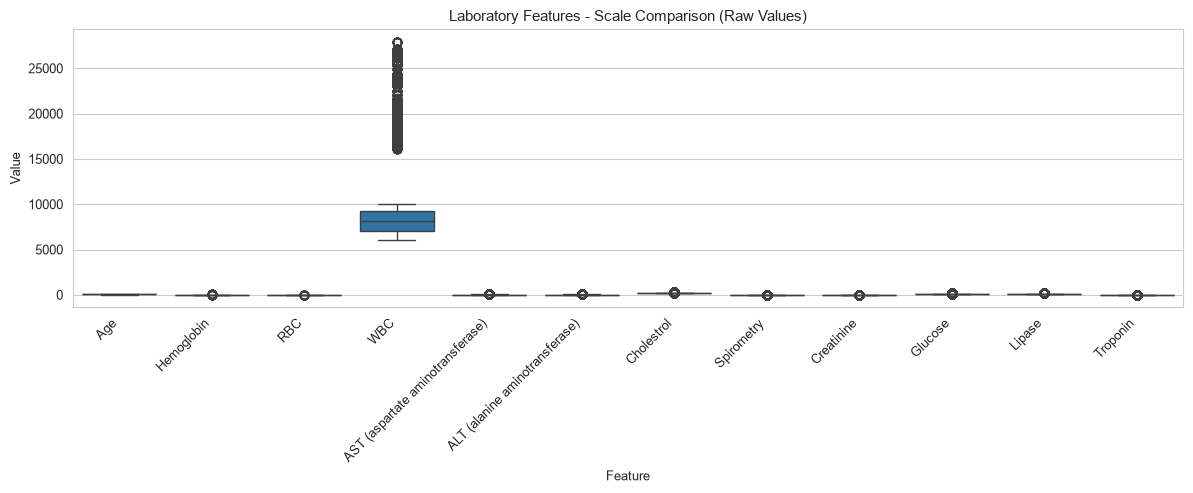

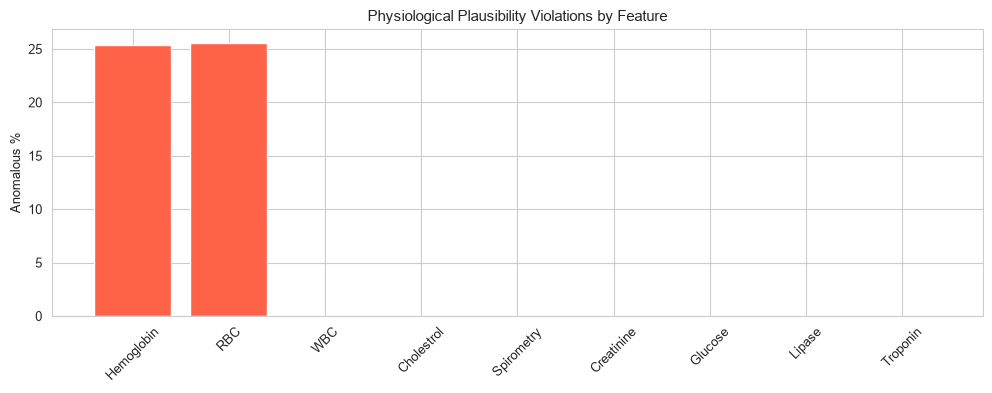

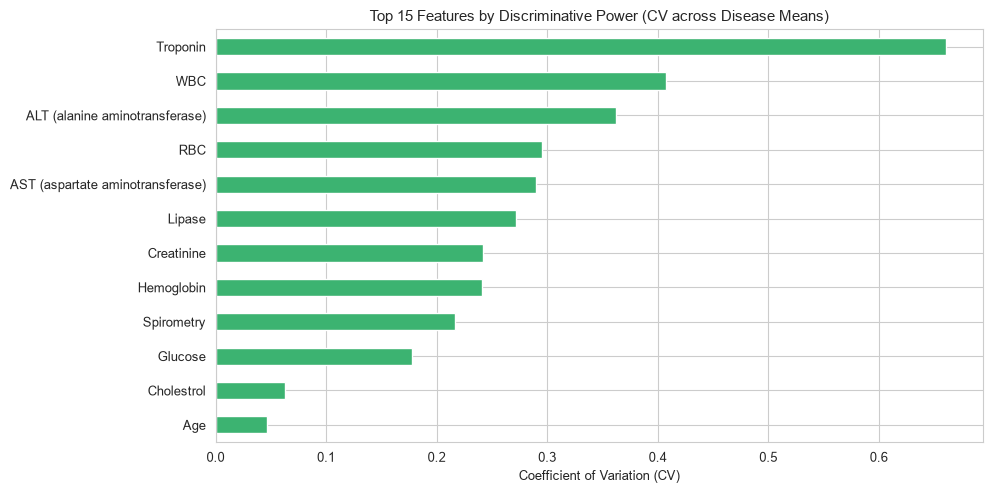

C:\Users\hotro\AppData\Local\Temp\ipykernel_3084\1947846056.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


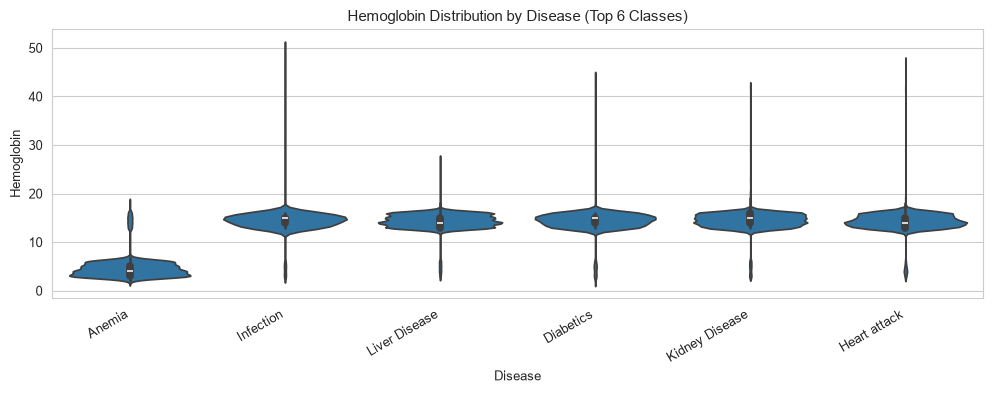

C:\Users\hotro\AppData\Local\Temp\ipykernel_3084\1947846056.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


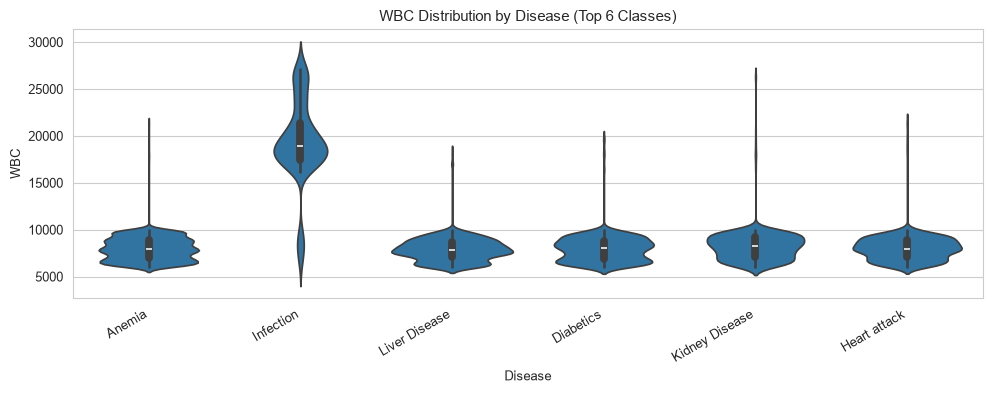

C:\Users\hotro\AppData\Local\Temp\ipykernel_3084\1947846056.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


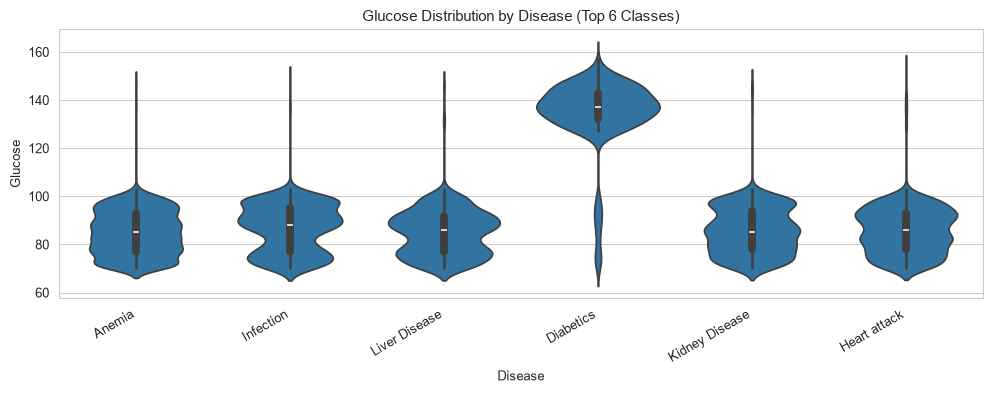

C:\Users\hotro\AppData\Local\Temp\ipykernel_3084\1947846056.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


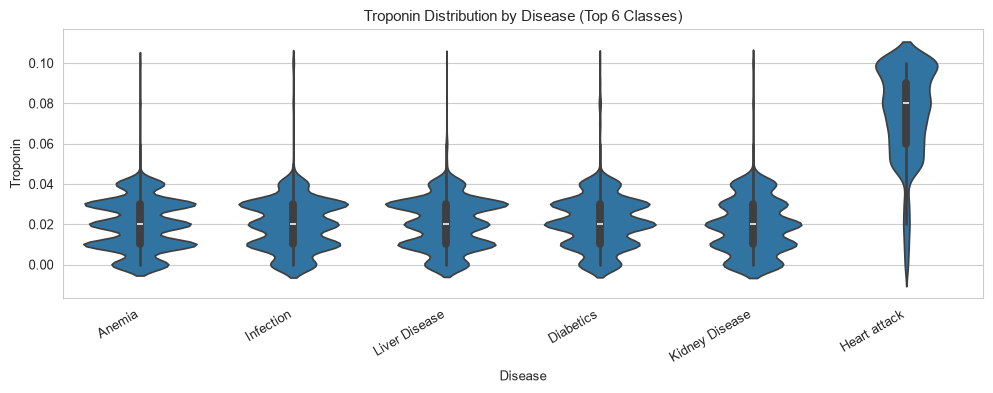

In [13]:
import pandas as pd
import numpy as np

# ============================================
# 1. LOAD DATA & BASIC PROFILE
# ============================================
df = pd.read_csv("../Dataset/laboratory_data.csv")

# Fix trailing space in target column if present
if "Disease " in df.columns:
    df = df.rename(columns={"Disease ": "Disease"})

target_col = "Disease"
feature_cols = [c for c in df.columns if c != target_col]

print("=" * 60)
print("1. DATA PROFILE & SCALE ANALYSIS")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Target: {target_col}")
print(f"Features: {len(feature_cols)} columns")

# Separate feature types
numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df[feature_cols].select_dtypes(include=["object"]).columns.tolist()

print(f"\nNumeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

# Scale analysis for numeric features
print("\nScale Analysis (numeric features):")
print(f"{'Feature':<20} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10} {'Range':>10}")
print("-" * 70)
for col in numeric_cols:
    vals = df[col].dropna()
    if len(vals) == 0:
        continue
    vmin, vmax = vals.min(), vals.max()
    vmean, vstd = vals.mean(), vals.std()
    print(f"{col:<20} {vmin:>10.2f} {vmax:>10.2f} {vmean:>10.2f} {vstd:>10.2f} {vmax-vmin:>10.2f}")

# Check categorical cardinality
if cat_cols:
    print(f"\nCategorical feature cardinality:")
    for col in cat_cols:
        uniques = df[col].unique()[:5]
        print(f"  {col}: {df[col].nunique()} unique values -> {list(uniques)}")

# ============================================
# 2. PHYSIOLOGICAL OUTLIERS & ANOMALIES
# ============================================
print("\n" + "=" * 60)
print("2. PHYSIOLOGICAL OUTLIERS & ANOMALIES")
print("=" * 60)

# Define physiological plausibility ranges (adult reference)
plausibility = {
    "Hemoglobin": (7.0, 20.0),
    "RBC": (2.0, 7.0),
    "WBC": (2000, 50000),
    "AST": (0, 500),
    "ALT": (0, 500),
    "Cholestrol": (50, 400),
    "Spirometry": (0.5, 8.0),
    "Creatinine": (0.3, 15.0),
    "Glucose": (30, 500),
    "Lipase": (0, 500),
    "Troponin": (0, 10)
}

print("\nPhysiological Plausibility Check:")
for col in numeric_cols:
    if col not in plausibility:
        continue
    vals = df[col].dropna()
    if len(vals) == 0:
        continue
    low, high = plausibility[col]
    below = (vals < low).sum()
    above = (vals > high).sum()
    total_anomaly = below + above
    pct = total_anomaly / len(vals) * 100
    print(f"  {col}:")
    print(f"    Range: [{vals.min():.2f}, {vals.max():.2f}]")
    print(f"    Below {low}: {below} ({below/len(vals)*100:.1f}%)")
    print(f"    Above {high}: {above} ({above/len(vals)*100:.1f}%)")
    if pct > 0:
        print(f"    -> Total anomalous: {total_anomaly} ({pct:.1f}%) - Review clinically!")

# IQR-based outlier detection per disease group
print(f"\nIQR Outlier Detection by Disease (key features):")
key_features = ["Hemoglobin", "WBC", "Glucose", "Troponin", "Creatinine"]
for feat in key_features:
    if feat not in df.columns:
        continue
    print(f"\n  {feat}:")
    for disease in df[target_col].unique()[:5]:
        sub = df[df[target_col] == disease][feat].dropna()
        if len(sub) < 10:
            continue
        q1, q3 = sub.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = sub[(sub < lower) | (sub > upper)]
        if len(outliers) > 0:
            print(f"    {disease}: {len(outliers)} outliers (range: [{outliers.min():.2f}, {outliers.max():.2f}])")

# ============================================
# 3. FEATURE-DISEASE RELEVANCE
# ============================================
print("\n" + "=" * 60)
print("3. FEATURE-DISEASE RELEVANCE")
print("=" * 60)

# Group statistics by disease
print("\nMean values by Disease (key features):")
grouped = df.groupby(target_col)[numeric_cols].mean().round(2)
print(grouped[key_features].to_string())

# Coefficient of Variation (CV) across diseases for each feature
print(f"\nFeature discriminative power (CV across disease means):")
disease_means = df.groupby(target_col)[numeric_cols].mean()
cv = (disease_means.std() / disease_means.mean()).sort_values(ascending=False)
print(f"{'Feature':<20} {'CV':>10}")
print("-" * 32)
for feat, val in cv.head(10).items():
    print(f"{feat:<20} {val:>10.3f}")
print("\n[!] Higher CV = more variation across diseases = potentially more discriminative.")

# ============================================
# 4. PROJECT GAPS & PREPARATION ROADMAP
# ============================================
print("\n" + "=" * 60)
print("4. PROJECT GAPS & PREPARATION ROADMAP")
print("=" * 60)

print(f"\nDataset Summary:")
print(f"  Samples: {len(df):,}")
print(f"  Diseases: {df[target_col].nunique()}")
print(f"  Features: {len(feature_cols)} ({len(numeric_cols)} numeric, {len(cat_cols)} categorical)")

print(f"\nWhat is PRESENT:")
print(f"  [x] Numeric lab values ({len(numeric_cols)} features)")
print(f"  [x] Categorical demographics: {cat_cols}")
print(f"  [x] Disease labels ({df[target_col].nunique()} classes)")

print(f"\nWhat is MISSING for robust AI training:")
print(f"  [ ] Symptom data: NO clinical symptoms, only lab values.")
print(f"  [ ] Vitals: NO blood pressure, heart rate, temperature, SpO2.")
print(f"  [ ] Medical history: NO comorbidities, medications, family history.")
print(f"  [ ] Temporal info: NO sample time, admission/discharge dates.")
print(f"  [ ] Metadata: NO patient ID, source hospital, device/assay info.")
print(f"  [ ] Missing value indicators: Some cells may be blank/missing.")

print(f"\nRECOMMENDED PREPARATION ROADMAP:")
print(f"  1. SCALING: Use StandardScaler or RobustScaler for numeric features (different units/scales).")
print(f"  2. IMPUTATION: KNN or MICE for missing values (biological data is correlated).")
print(f"  3. ENCODING: One-Hot or Target Encoding for Gender.")
print(f"  4. OUTLIER HANDLING: Winsorize or flag extreme values rather than drop (medical value).")
print(f"  5. CLASS IMBALANCE: Check distribution of Disease classes.")
print(f"  6. FEATURE SELECTION: Remove low-variance features, use correlation analysis.")
print(f"  7. BASELINE MODEL: Start with XGBoost / Random Forest (handles mixed scales well).")

print("\n" + "=" * 60)
print("EDA COMPLETE - No data was modified.")

# ============================================
# 5. VISUALIZATION - Laboratory Data
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 9
sns.set_style("whitegrid")

# --- Scale comparison (boxplot of numeric features) ---
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = df[numeric_cols].copy()
plot_df = plot_df.melt(var_name="Feature", value_name="Value")
plot_df = plot_df.dropna()
sns.boxplot(data=plot_df, x="Feature", y="Value", ax=ax)
ax.set_title("Laboratory Features - Scale Comparison (Raw Values)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Physiological plausibility check visualization ---
plausibility_counts = {}
for col in numeric_cols:
    if col not in plausibility:
        continue
    vals = df[col].dropna()
    if len(vals) == 0:
        continue
    low, high = plausibility[col]
    below = (vals < low).sum()
    above = (vals > high).sum()
    total = below + above
    plausibility_counts[col] = total / len(vals) * 100

if plausibility_counts:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(plausibility_counts.keys(), plausibility_counts.values(), color="tomato")
    ax.set_ylabel("Anomalous %")
    ax.set_title("Physiological Plausibility Violations by Feature")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# --- Feature-Disease Relevance: CV bar chart ---
if len(cv) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    cv.head(15).plot(kind="barh", color="mediumseagreen", ax=ax)
    ax.set_xlabel("Coefficient of Variation (CV)")
    ax.set_title("Top 15 Features by Discriminative Power (CV across Disease Means)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

# --- Key features distribution by disease (violin plot) ---
for feat in ["Hemoglobin", "WBC", "Glucose", "Troponin"]:
    if feat not in df.columns:
        continue
    fig, ax = plt.subplots(figsize=(10, 4))
    diseases_to_plot = df[target_col].value_counts().head(6).index
    sub = df[df[target_col].isin(diseases_to_plot)]
    sns.violinplot(data=sub, x=target_col, y=feat, ax=ax, inner="box")
    ax.set_title(f"{feat} Distribution by Disease (Top 6 Classes)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
print("=" * 60)


# 4. EDA - Phân tích khám phá dữ liệu Personalized Medication Dataset

**Mục tiêu:** Thực hiện EDA chuyên sâu trên bộ dữ liệu `personalized_medication_dataset.csv` (bệnh nhân, chẩn đoán, triệu chứng, thuốc, liều lượng, hiệu quả điều trị) **trước khi tiến hành làm sạch**. Chỉ đọc, phân tích và báo cáo. **TUYỆT ĐỐI KHÔNG tự động clean dữ liệu.**

---

## Yêu cầu phân tích

### 1. Data Structural Integrity
- Kiểm tra logic giữa các cột (ví dụ: BMI có khớp với Height/Weight không?).
- Phân tích các cột dạng chuỗi (Symptoms, Drug_Allergies) và đề xuất cách tách biến (Feature Extraction) phù hợp cho ML.

### 2. Outlier & Safety Validation
- Phát hiện các giá trị có khả năng là sai sót nhập liệu nguy hiểm (ví dụ: liều lượng thuốc vô lý so với tiêu chuẩn y tế).
- Đánh giá ý nghĩa của giá trị "None" trong các cột medication/allergy (thiếu hay thuộc tính thực tế).

### 3. Data Quality Gap
- Đánh giá sự phân bố của dữ liệu (có bị lệch/imbalanced không).
- Những thông tin nào còn thiếu để mô hình AI hiểu được bản chất "bệnh lý" thay vì chỉ học theo thống kê bảng.

### 4. Preparation Roadmap
- Đề xuất thứ tự ưu tiên xử lý (Encoding biến phân loại nào trước, xử lý biến triệu chứng ra sao).

---

**Lưu ý:** Output chỉ dùng để đánh giá chất lượng dữ liệu và lập kế hoạch tiền xử lý. Không sửa đổi dữ liệu gốc.

1. DATA STRUCTURAL INTEGRITY
Shape: 1000 rows x 17 columns
Target: Recommended_Medication
Features: 16 columns

BMI Consistency Check:
  Rows with BMI mismatch > 1.0 unit: 916 (91.6%)
  Sample mismatches:
Patient_ID  Height_cm  Weight_kg  BMI  BMI_calculated  BMI_diff
     P0001      196.3       88.7 21.1       23.018818  1.918818
     P0002      195.6       90.5 30.2       23.654342  6.545658
     P0003      168.2       87.0 27.0       30.751568  3.751568
     P0004      188.9       81.4 26.9       22.811849  4.088151
     P0005      157.0       64.2 33.3       26.045681  7.254319

String/List-like columns analysis:
  Chronic_Conditions:
    Sample values: ['Hypertension', 'Hypertension', 'Hypertension']
    Multi-value entries (contains comma): 0 (0.0%)
  Drug_Allergies:
    Sample values: ['Penicillin', 'Sulfa', 'Penicillin']
    Multi-value entries (contains comma): 0 (0.0%)
  Genetic_Disorders:
    Sample values: ['Cystic Fibrosis', 'Cystic Fibrosis', 'Cystic Fibrosis']
    Multi-

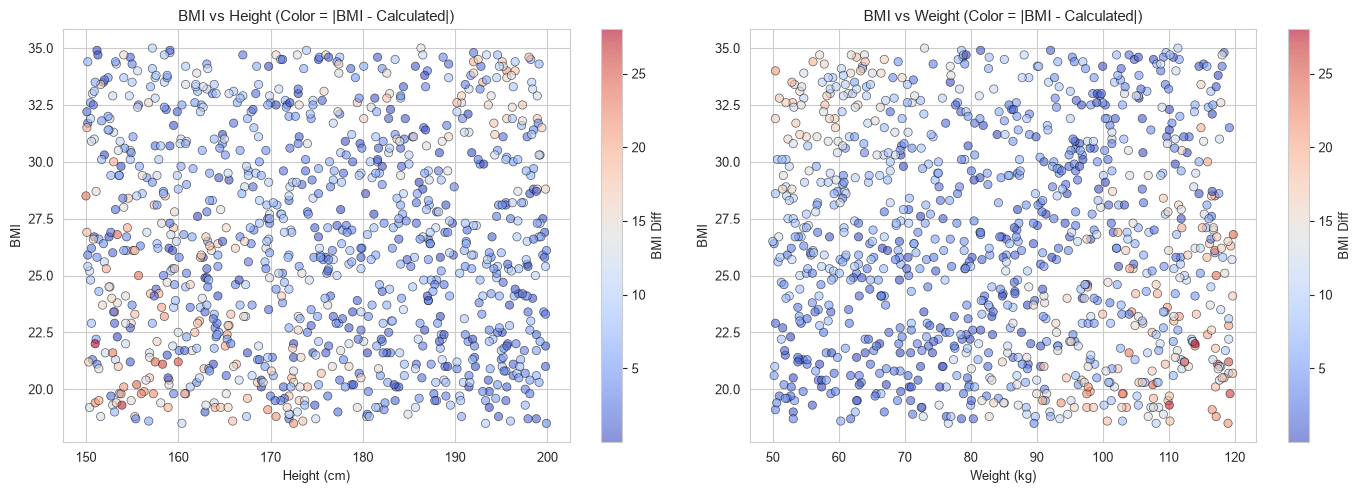

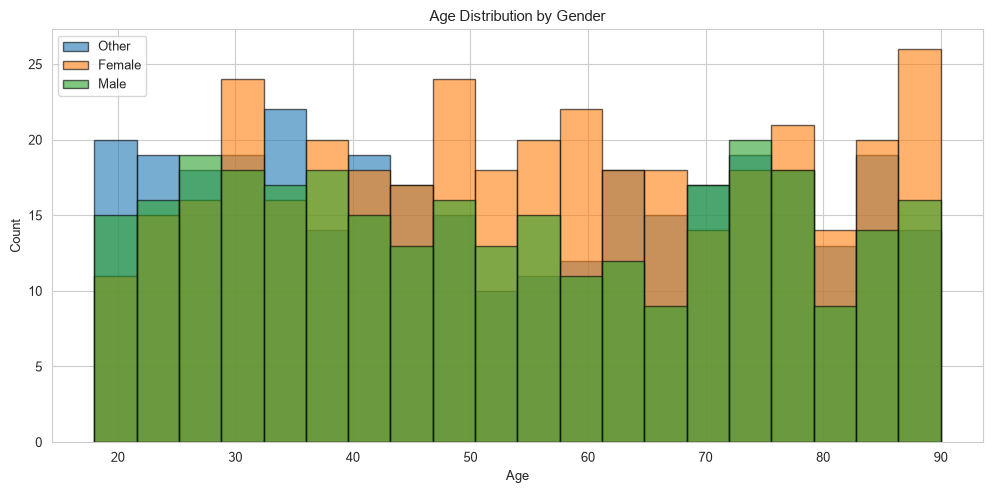

<Figure size 1200x600 with 0 Axes>

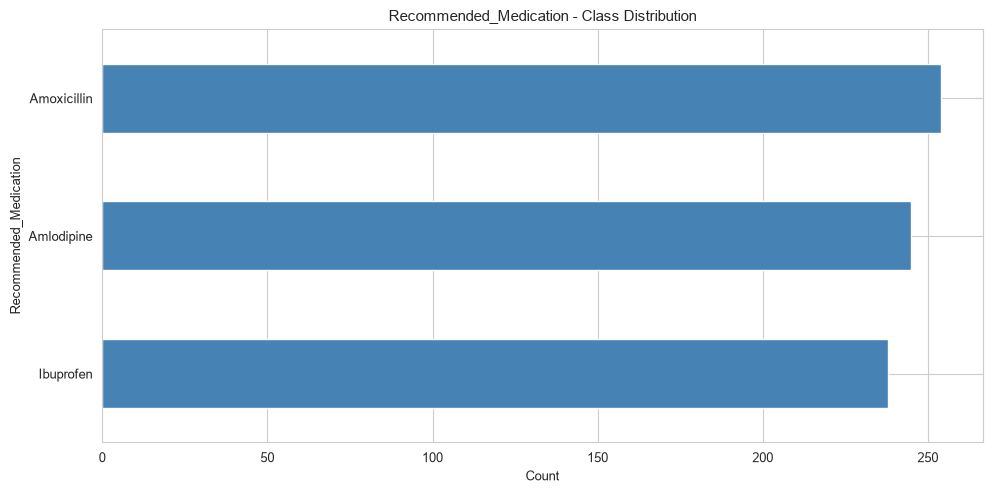

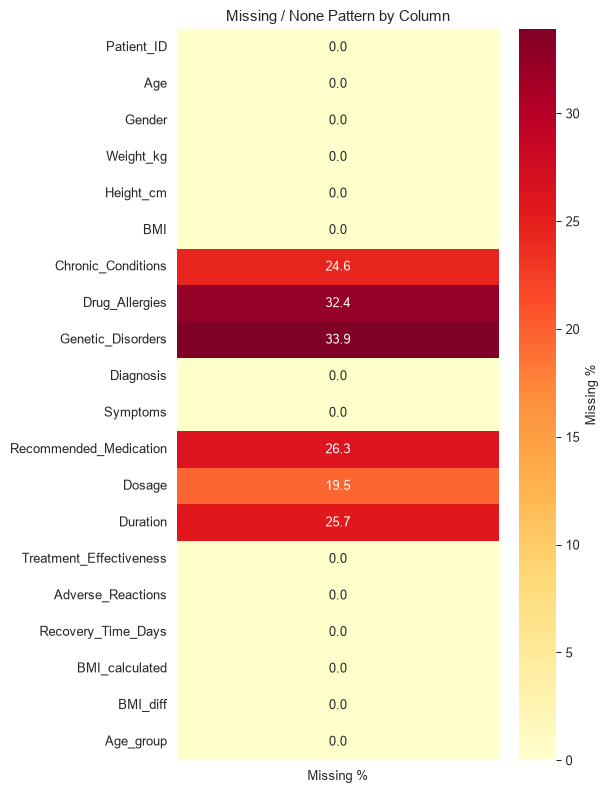

In [15]:
import pandas as pd
import numpy as np
import re

# ============================================
# 1. LOAD DATA & BASIC PROFILE
# ============================================
df = pd.read_csv("../Dataset/personalized_medication_dataset.csv")

target_col = "Recommended_Medication"
feature_cols = [c for c in df.columns if c != target_col]

print("=" * 60)
print("1. DATA STRUCTURAL INTEGRITY")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Target: {target_col}")
print(f"Features: {len(feature_cols)} columns")

# Check BMI consistency with Height/Weight
if "BMI" in df.columns and "Height_cm" in df.columns and "Weight_kg" in df.columns:
    df["BMI_calculated"] = df["Weight_kg"] / (df["Height_cm"] / 100) ** 2
    df["BMI_diff"] = (df["BMI"] - df["BMI_calculated"]).abs()
    mismatch = df[df["BMI_diff"] > 1.0]
    print(f"\nBMI Consistency Check:")
    print(f"  Rows with BMI mismatch > 1.0 unit: {len(mismatch)} ({len(mismatch)/len(df)*100:.1f}%)")
    if len(mismatch) > 0:
        print(f"  Sample mismatches:")
        print(mismatch[["Patient_ID", "Height_cm", "Weight_kg", "BMI", "BMI_calculated", "BMI_diff"]].head(5).to_string(index=False))

# Analyze string/list-like columns for feature extraction
string_cols = ["Chronic_Conditions", "Drug_Allergies", "Genetic_Disorders", "Diagnosis", "Symptoms", "Recommended_Medication", "Dosage", "Duration", "Treatment_Effectiveness", "Adverse_Reactions"]
print(f"\nString/List-like columns analysis:")
for col in string_cols:
    if col not in df.columns:
        continue
    sample = df[col].dropna().head(3).tolist()
    print(f"  {col}:")
    print(f"    Sample values: {sample}")
    multi = df[col].astype(str).str.contains(",")
    print(f"    Multi-value entries (contains comma): {multi.sum()} ({multi.sum()/len(df)*100:.1f}%)")

# ============================================
# 2. OUTLIER & SAFETY VALIDATION
# ============================================
print("\n" + "=" * 60)
print("2. OUTLIER & SAFETY VALIDATION")
print("=" * 60)

# Check Dosage values
if "Dosage" in df.columns:
    print(f"\nDosage values distribution:")
    dosage_vals = df["Dosage"].value_counts()
    print(dosage_vals.head(10).to_string())
    suspicious = df[df["Dosage"].astype(str).str.contains("None") == False]
    print(f"\nNon-None dosage entries: {len(suspicious)}")
    suspicious["dosage_num"] = pd.to_numeric(suspicious["Dosage"].str.extract(r"(\d+)")[0], errors="coerce")
    if suspicious["dosage_num"].notna().sum() > 0:
        print(f"  Dosage numeric stats: min={suspicious['dosage_num'].min():.0f}, max={suspicious['dosage_num'].max():.0f}, mean={suspicious['dosage_num'].mean():.1f}")

# Check "None" semantics
print(f"\n'None' semantics analysis:")
for col in ["Drug_Allergies", "Genetic_Disorders", "Recommended_Medication", "Dosage", "Adverse_Reactions"]:
    if col not in df.columns:
        continue
    none_count = (df[col].astype(str) == "None").sum()
    print(f"  {col}: {none_count} 'None' values ({none_count/len(df)*100:.1f}%)")

# Age distribution
if "Age" in df.columns:
    print(f"\nAge distribution:")
    print(f"  Min: {df['Age'].min()}, Max: {df['Age'].max()}, Mean: {df['Age'].mean():.1f}")
    bins = [0, 18, 35, 50, 65, 100]
    labels = ["0-18", "19-35", "36-50", "51-65", "66+"]
    df["Age_group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)
    print(df["Age_group"].value_counts().to_string())

# ============================================
# 3. DATA QUALITY GAP
# ============================================
print("\n" + "=" * 60)
print("3. DATA QUALITY GAP")
print("=" * 60)

# Target distribution
print(f"\nTarget distribution (Recommended_Medication):")
print(df[target_col].value_counts().to_string())

target_counts = df[target_col].value_counts()
print(f"\nClass imbalance ratio (max/min): {target_counts.iloc[0]/target_counts.iloc[-1]:.1f}x")

# Missing/None patterns
print(f"\nMissing/None patterns:")
for col in df.columns:
    none_count = (df[col].astype(str) == "None").sum()
    null_count = df[col].isna().sum()
    total_missing = none_count + null_count
    if total_missing > 0:
        print(f"  {col}: {total_missing} missing/None ({total_missing/len(df)*100:.1f}%)")

duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# ============================================
# 4. PREPARATION ROADMAP
# ============================================
print("\n" + "=" * 60)
print("4. PREPARATION ROADMAP")
print("=" * 60)

print(f"\nRecommended processing priority:")
print(f"  1. STRUCTURAL: Fix BMI mismatch rows (if any) or standardize calculation method.")
print(f"  2. SAFETY: Validate dosage ranges against medical standards (consult pharmacist).")
print(f"  3. ENCODING: Encode categorical variables (Gender, Treatment_Effectiveness, Adverse_Reactions).")
print(f"  4. FEATURE EXTRACTION: Split multi-value columns (Symptoms, Drug_Allergies) into binary indicators.")
print(f"  5. IMPUTATION: Decide 'None' strategy per column (keep as category vs impute).")
print(f"  6. SCALING: Normalize numeric features (Age, Weight, Height, BMI, Recovery_Time).")
print(f"  7. TARGET ENCODING: Encode Recommended_Medication (multi-class classification).")
print(f"  8. SPLIT: Stratified train/val/test split considering class imbalance.")

print("\n" + "=" * 60)
print("EDA COMPLETE - No data was modified.")

# ============================================
# 5. VISUALIZATION - Personalized Medication
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 9
sns.set_style("whitegrid")

# --- BMI vs Height/Weight scatter ---
if "BMI" in df.columns and "Height_cm" in df.columns and "Weight_kg" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # BMI vs Height
    scatter1 = axes[0].scatter(df["Height_cm"], df["BMI"], c=df["BMI_diff"], cmap="coolwarm", alpha=0.6, edgecolors="black", linewidth=0.5)
    axes[0].set_xlabel("Height (cm)")
    axes[0].set_ylabel("BMI")
    axes[0].set_title("BMI vs Height (Color = |BMI - Calculated|)")
    plt.colorbar(scatter1, ax=axes[0], label="BMI Diff")
    
    # BMI vs Weight
    scatter2 = axes[1].scatter(df["Weight_kg"], df["BMI"], c=df["BMI_diff"], cmap="coolwarm", alpha=0.6, edgecolors="black", linewidth=0.5)
    axes[1].set_xlabel("Weight (kg)")
    axes[1].set_ylabel("BMI")
    axes[1].set_title("BMI vs Weight (Color = |BMI - Calculated|)")
    plt.colorbar(scatter2, ax=axes[1], label="BMI Diff")
    
plt.tight_layout()
plt.show()

# --- Age distribution by Gender ---
if "Age" in df.columns and "Gender" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    for gender in df["Gender"].unique():
        sub = df[df["Gender"] == gender]["Age"]
        ax.hist(sub, bins=20, alpha=0.6, label=gender, edgecolor="black")
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")
    ax.set_title("Age Distribution by Gender")
    ax.legend()
plt.tight_layout()
plt.show()

# --- Dosage numeric distribution ---
if "dosage_num" in locals() or "dosage_num" in globals():
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(suspicious["dosage_num"].dropna(), bins=30, color="orange", edgecolor="black", alpha=0.7)
    ax.set_xlabel("Dosage (numeric extracted)")
    ax.set_ylabel("Count")
    ax.set_title("Dosage Distribution (Extracted Numeric Values)")
plt.tight_layout()
plt.show()

# --- Target class distribution ---
fig, ax = plt.subplots(figsize=(10, 5))
target_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Count")
ax.set_title("Recommended_Medication - Class Distribution")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# --- Missing/None pattern heatmap ---
missing_matrix = pd.DataFrame()
for col in df.columns:
    none_count = (df[col].astype(str) == "None").sum()
    null_count = df[col].isna().sum()
    missing_matrix.loc[col, "Missing %"] = (none_count + null_count) / len(df) * 100

fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(missing_matrix, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Missing %"})
ax.set_title("Missing / None Pattern by Column")
plt.tight_layout()
plt.show()
print("=" * 60)
